Input: (1, 3, 227, 227)
Conv1+ReLU: (1, 96, 55, 55)
LRN1: (1, 96, 55, 55)
Pool1: (1, 96, 27, 27)
Conv2(g=2)+ReLU: (1, 256, 27, 27)
LRN2: (1, 256, 27, 27)
Pool2: (1, 256, 13, 13)
Conv3+ReLU: (1, 384, 13, 13)
Conv4(g=2)+ReLU: (1, 384, 13, 13)
Conv5(g=2)+ReLU: (1, 256, 13, 13)
Pool5: (1, 256, 6, 6)
Flatten: (1, 9216)
FC6+ReLU+Drop: (1, 4096)
FC7+ReLU+Drop: (1, 4096)
FC8(Logits): (1, 1000)
logits sample: tensor([-0.0017,  0.0079, -0.0184, -0.0057,  0.0107])


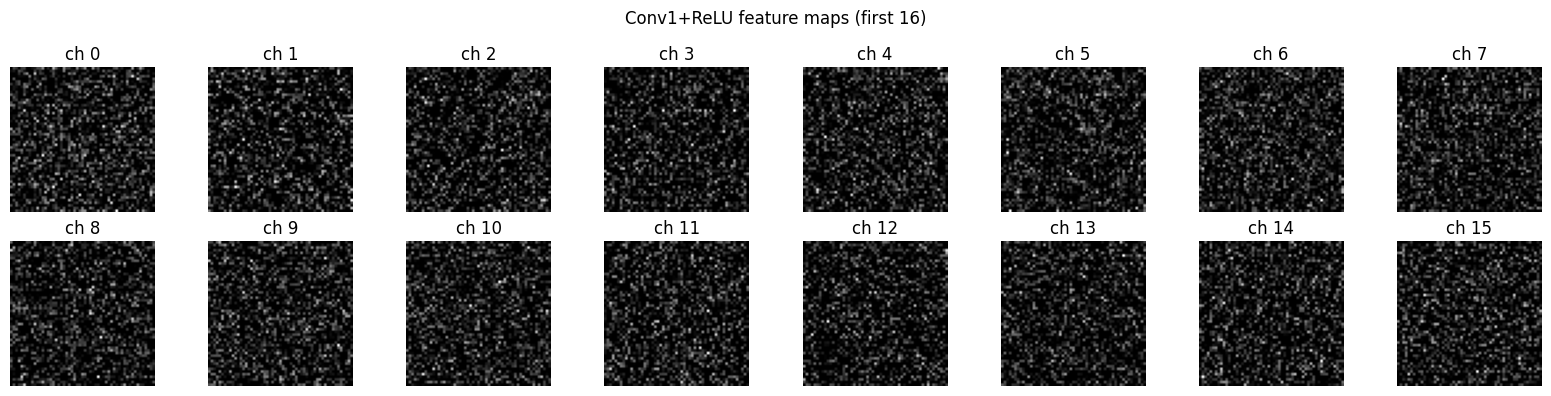

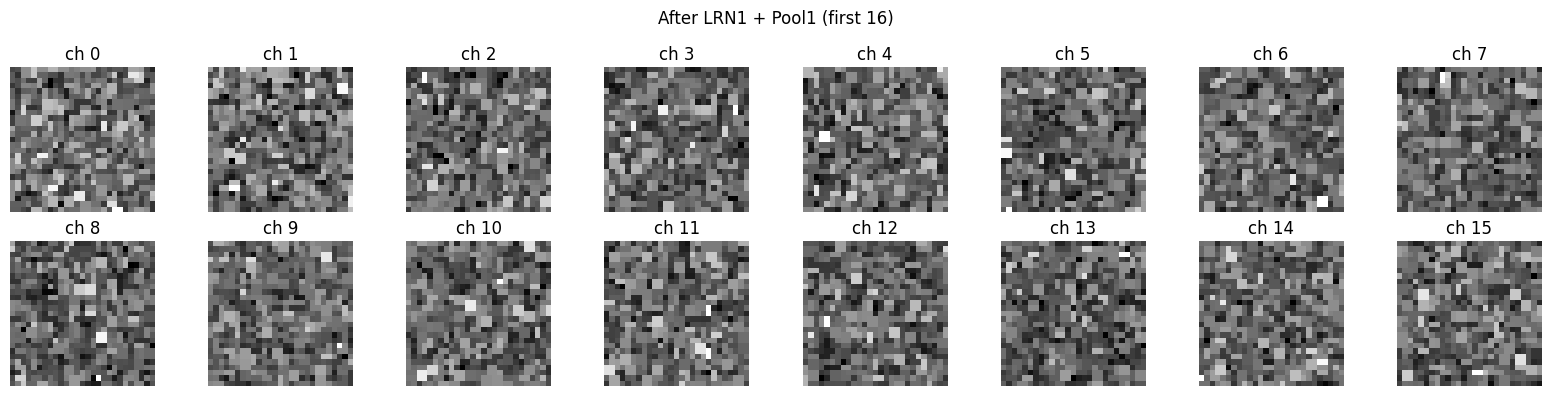

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class AlexNet2012(nn.Module):
    """
    AlexNet (Krizhevsky et al., 2012) - 논문 흐름에 가깝게 구현
    - Input: 227x227x3
    - LRN 포함
    - group conv(2) 포함 (원 논문 GPU 분할을 반영)
    """
    def __init__(self, num_classes=1000):
        super().__init__()

        # --- Feature extractor ---
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0)  # 227 -> 55
        self.lrn1  = nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2)                  # 55 -> 27

        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2, groups=2)
        self.lrn2  = nn.LocalResponseNorm(size=5, alpha=1e-4, beta=0.75, k=2.0)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2)                  # 27 -> 13

        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)

        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1, groups=2)

        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1, groups=2)
        self.pool5 = nn.MaxPool2d(kernel_size=3, stride=2)                  # 13 -> 6

        # --- Classifier ---
        # After pool5: (N, 256, 6, 6) => 256*6*6 = 9216
        self.fc6 = nn.Linear(256 * 6 * 6, 4096)
        self.drop6 = nn.Dropout(p=0.5)

        self.fc7 = nn.Linear(4096, 4096)
        self.drop7 = nn.Dropout(p=0.5)

        self.fc8 = nn.Linear(4096, num_classes)

    def forward(self, x, verbose=False):
        # x: (N,3,227,227)
        if verbose: print("Input:", tuple(x.shape))

        x = self.conv1(x)
        x = F.relu(x)
        if verbose: print("Conv1+ReLU:", tuple(x.shape))     # (N,96,55,55)
        x = self.lrn1(x)
        if verbose: print("LRN1:", tuple(x.shape))
        x = self.pool1(x)
        if verbose: print("Pool1:", tuple(x.shape))          # (N,96,27,27)

        x = self.conv2(x)
        x = F.relu(x)
        if verbose: print("Conv2(g=2)+ReLU:", tuple(x.shape))# (N,256,27,27)
        x = self.lrn2(x)
        if verbose: print("LRN2:", tuple(x.shape))
        x = self.pool2(x)
        if verbose: print("Pool2:", tuple(x.shape))          # (N,256,13,13)

        x = self.conv3(x)
        x = F.relu(x)
        if verbose: print("Conv3+ReLU:", tuple(x.shape))     # (N,384,13,13)

        x = self.conv4(x)
        x = F.relu(x)
        if verbose: print("Conv4(g=2)+ReLU:", tuple(x.shape))# (N,384,13,13)

        x = self.conv5(x)
        x = F.relu(x)
        if verbose: print("Conv5(g=2)+ReLU:", tuple(x.shape))# (N,256,13,13)
        x = self.pool5(x)
        if verbose: print("Pool5:", tuple(x.shape))          # (N,256,6,6)

        x = torch.flatten(x, 1)
        if verbose: print("Flatten:", tuple(x.shape))        # (N,9216)

        x = self.fc6(x)
        x = F.relu(x)
        x = self.drop6(x)
        if verbose: print("FC6+ReLU+Drop:", tuple(x.shape))  # (N,4096)

        x = self.fc7(x)
        x = F.relu(x)
        x = self.drop7(x)
        if verbose: print("FC7+ReLU+Drop:", tuple(x.shape))  # (N,4096)

        x = self.fc8(x)
        if verbose: print("FC8(Logits):", tuple(x.shape))    # (N,num_classes)
        return x


@torch.no_grad()
def visualize_feature_maps(feature_tensor, max_channels=16, title="Feature maps"):
    """
    feature_tensor: (1, C, H, W) expected
    max_channels: 보여줄 채널 개수
    """
    assert feature_tensor.dim() == 4 and feature_tensor.size(0) == 1
    C = feature_tensor.size(1)
    k = min(C, max_channels)

    # normalize each channel for display
    maps = feature_tensor[0, :k].cpu()
    ncols = 8
    nrows = (k + ncols - 1) // ncols

    plt.figure(figsize=(2*ncols, 2*nrows))
    for i in range(k):
        m = maps[i]
        m = (m - m.min()) / (m.max() - m.min() + 1e-8)
        ax = plt.subplot(nrows, ncols, i+1)
        ax.imshow(m, cmap="gray")
        ax.set_title(f"ch {i}")
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def run_alexnet_flow_demo():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = AlexNet2012(num_classes=1000).to(device)
    model.eval()

    # 더미 입력(논문 기준 227x227)
    x = torch.randn(1, 3, 227, 227, device=device)

    # 1) verbose로 shape 흐름 확인
    logits = model(x, verbose=True)
    print("logits sample:", logits[0, :5].cpu())

    # 2) 중간 feature map 시각화: conv1 결과를 뽑아보기
    # (forward hook 대신 여기서는 직접 단계 실행)
    y1 = F.relu(model.conv1(x))
    visualize_feature_maps(y1, max_channels=16, title="Conv1+ReLU feature maps (first 16)")

    y1p = model.pool1(model.lrn1(y1))
    visualize_feature_maps(y1p, max_channels=16, title="After LRN1 + Pool1 (first 16)")


if __name__ == "__main__":
    run_alexnet_flow_demo()
